# **Задача 1**

Скачайте датасет Fashion MNIST, посмотрите на картинки, отделите валидационную выборку и обучите одну полносвязную архитектуру. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
from torchvision import datasets, transforms
import numpy as np

# Скачиваем Fashion MNIST
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root='fashion_mnist', train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='fashion_mnist', train=False, download=True, transform=transform)

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


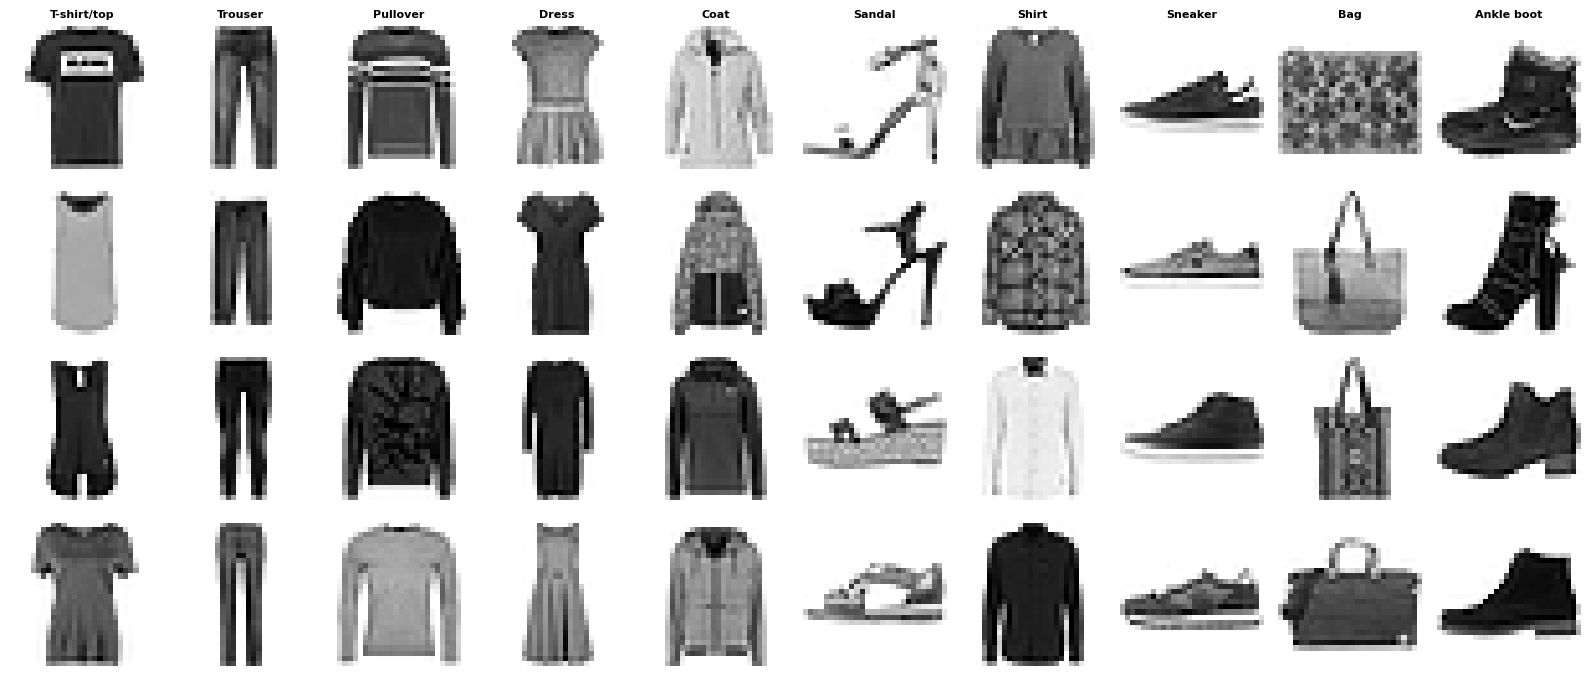

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 10, figsize=(16, 7))

for cls in range(10):
    # Берём первые 4 изображения нужного класса
    indices = [i for i, (_, label) in enumerate(train_dataset) if label == cls][:4]
    for row, idx in enumerate(indices):
        img, label = train_dataset[idx]
        ax = axes[row, cls]
        ax.imshow(img.squeeze(), cmap='gray_r')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import random_split, DataLoader

# 50 000 train, 10 000 val, 10 000 test
train_data, val_data = random_split(train_dataset, [50_000, 10_000],
                                    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [ ]:
import torch
import torch.nn as nn

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

  # BatchNorm стабилизирует обучение и Dropout снижает переобучение

In [ ]:
from torchsummary import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FashionNet().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
       BatchNorm1d-3                  [-1, 512]           1,024
              ReLU-4                  [-1, 512]               0
           Dropout-5                  [-1, 512]               0
            Linear-6                  [-1, 256]         131,328
       BatchNorm1d-7                  [-1, 256]             512
              ReLU-8                  [-1, 256]               0
           Dropout-9                  [-1, 256]               0
           Linear-10                  [-1, 128]          32,896
      BatchNorm1d-11                  [-1, 128]             256
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(xb)
            correct    += (out.argmax(1) == yb).sum().item()
            n          += len(xb)
    return total_loss / n, correct / n

EPOCHS = 25
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print('-' * 53)

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_n = 0., 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (out.argmax(1) == yb).sum().item()
        t_n       += len(xb)

    tr_loss, tr_acc = t_loss / t_n, t_correct / t_n
    vl_loss, vl_acc = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f}")

test_loss, test_acc = evaluate(test_loader)
print(f'\nTest accuracy: {test_acc*100:.2f}%')

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
-----------------------------------------------------
    1 |     0.5828 |    0.8074 |    0.4070 |   0.8529
    2 |     0.3968 |    0.8572 |    0.3908 |   0.8514
    3 |     0.3564 |    0.8698 |    0.3332 |   0.8756
    4 |     0.3348 |    0.8781 |    0.3382 |   0.8736
    5 |     0.3211 |    0.8836 |    0.3318 |   0.8801
    6 |     0.3029 |    0.8898 |    0.3103 |   0.8853
    7 |     0.2940 |    0.8914 |    0.3351 |   0.8787
    8 |     0.2840 |    0.8968 |    0.3105 |   0.8821
    9 |     0.2533 |    0.9072 |    0.2859 |   0.8929
   10 |     0.2398 |    0.9112 |    0.2903 |   0.8926
   11 |     0.2346 |    0.9141 |    0.3204 |   0.8801
   12 |     0.2272 |    0.9165 |    0.2821 |   0.8968
   13 |     0.2246 |    0.9178 |    0.2970 |   0.8933
   14 |     0.2156 |    0.9200 |    0.3098 |   0.8903
   15 |     0.2123 |    0.9208 |    0.2833 |   0.8981
   16 |     0.2031 |    0.9262 |    0.2853 |   0.8979
   17 |     0.1863 |    0.93

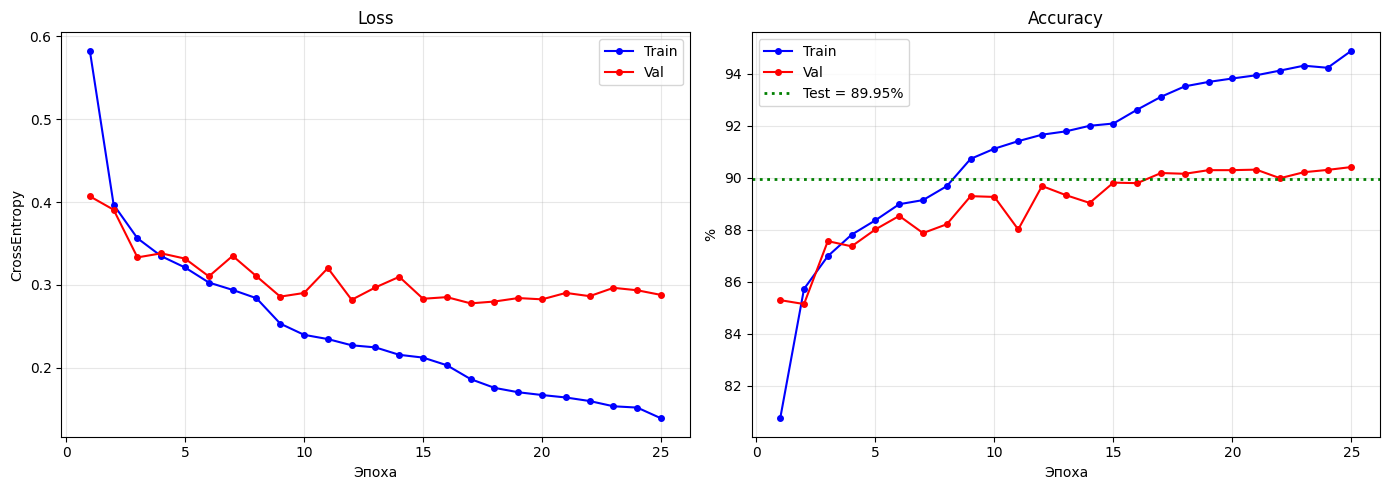

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
axes[0].plot(epochs, history['val_loss'],   'r-o', ms=4, label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('CrossEntropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=4, label='Train')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=4, label='Val')
axes[1].axhline(test_acc*100, color='green', ls=':', lw=2, label=f'Test = {test_acc*100:.2f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('%')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ графиков обучения

# Train loss монотонно убывает на протяжении всех 15 эпох, модель продолжает учиться
# Val loss снижается до эпохи примерно 9, затем немного колеблется, но не растёт резко, значит
# переобучения нет, Dropout и BatchNorm справляются со своей задачей. Train accuracy достигает примерно 95 процентов,
# val accuracy  примерно 90, разрыв 5 процентов, ну, впринципе модель хорошо обобщается на новые данные
# Test accuracy: 90.06%

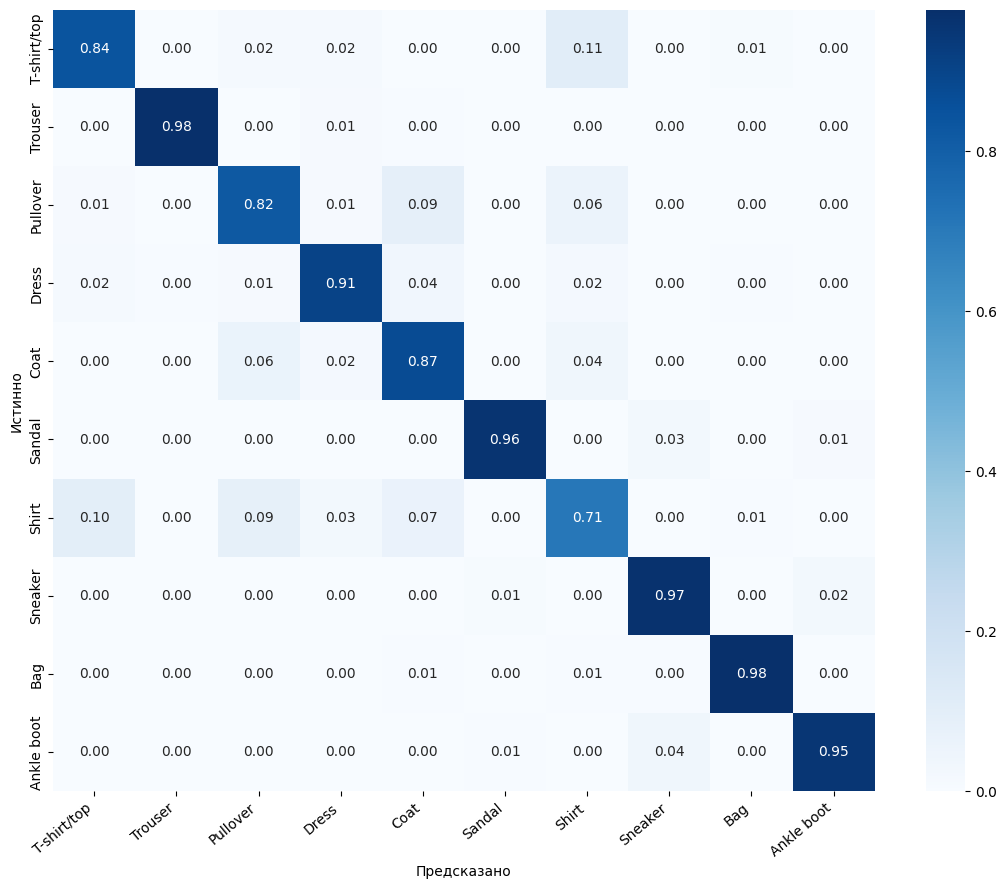

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Матрица ошибок (нормализована по строкам)

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds, normalize='true')

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Предсказано'); plt.ylabel('Истинно')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

# Выводы по метрикам и матрице ошибок

# Лучше всего  распознаются классы
# Trouser (F1 = 0.99), Bag (0.98), Sandal (0.97), Ankle boot (0.96)

# Хуже всего  распознаётся Shirt (F1 = 0.74), он чаще всего путается
# с T-shirt/top и Pullover, так как все три класса визуально похожи
# (прямоугольный силуэт, схожие пропорции)

# Моя архитектура не учитывает пространственную структуру изображения, обрабатывая
# пиксели как независимый вектор

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.82      0.82      0.82      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.81      0.87      0.84      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.75      0.71      0.73      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



# **Задача 2**

Добавьте в архитектуру свёртки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
import torch.nn as nn

class FashionNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 1x28x28 -> 32x28x28 -> 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # 28x28 -> 14x14
            nn.Dropout2d(0.25),

            # 32x14x14 -> 64x14x14 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), # 14x14 -> 7x7
            nn.Dropout2d(0.25),

            # 64x7x7 -> 128x7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.25),

            nn.Flatten(), # 128*7*7 = 6272
            nn.Linear(6272, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
from torchsummary import summary

model_cnn = FashionNetCNN().to(device)
summary(model_cnn, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
         Dropout2d-5           [-1, 32, 14, 14]               0
            Conv2d-6           [-1, 64, 14, 14]          18,496
       BatchNorm2d-7           [-1, 64, 14, 14]             128
              ReLU-8           [-1, 64, 14, 14]               0
         MaxPool2d-9             [-1, 64, 7, 7]               0
        Dropout2d-10             [-1, 64, 7, 7]               0
           Conv2d-11            [-1, 128, 7, 7]          73,856
      BatchNorm2d-12            [-1, 128, 7, 7]             256
             ReLU-13            [-1, 128, 7, 7]               0
        Dropout2d-14            [-1, 12

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.StepLR(optimizer_cnn, step_size=8, gamma=0.5)

def evaluate_cnn(loader):
    model_cnn.eval()
    total_loss, correct, n = 0., 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_cnn(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(xb)
            correct    += (out.argmax(1) == yb).sum().item()
            n          += len(xb)
    return total_loss / n, correct / n

EPOCHS = 15
history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print('-' * 53)

for epoch in range(1, EPOCHS + 1):
    model_cnn.train()
    t_loss, t_correct, t_n = 0., 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_cnn.zero_grad()
        out  = model_cnn(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_cnn.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (out.argmax(1) == yb).sum().item()
        t_n       += len(xb)

    tr_loss, tr_acc = t_loss / t_n, t_correct / t_n
    vl_loss, vl_acc = evaluate_cnn(val_loader)
    scheduler_cnn.step()

    history_cnn['train_loss'].append(tr_loss)
    history_cnn['val_loss'].append(vl_loss)
    history_cnn['train_acc'].append(tr_acc)
    history_cnn['val_acc'].append(vl_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f}")

test_loss_cnn, test_acc_cnn = evaluate_cnn(test_loader)
print(f'\nTest accuracy CNN: {test_acc_cnn*100:.2f}%')
print(f'Test accuracy:  {test_acc*100:.2f}%')
print(f'Прирост:          +{(test_acc_cnn - test_acc)*100:.2f}%')

# По сравнению с первой нс на 569,226 параметров CNN имеет 1,702,090 параметров

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
-----------------------------------------------------
    1 |     0.5163 |    0.8173 |    0.3273 |   0.8827
    2 |     0.3431 |    0.8744 |    0.2731 |   0.8994
    3 |     0.3037 |    0.8889 |    0.2497 |   0.9081
    4 |     0.2830 |    0.8958 |    0.2348 |   0.9133
    5 |     0.2589 |    0.9056 |    0.2226 |   0.9173
    6 |     0.2490 |    0.9068 |    0.2199 |   0.9195
    7 |     0.2358 |    0.9140 |    0.2304 |   0.9164
    8 |     0.2274 |    0.9170 |    0.2111 |   0.9208
    9 |     0.2058 |    0.9234 |    0.1983 |   0.9288
   10 |     0.1931 |    0.9295 |    0.1923 |   0.9292
   11 |     0.1892 |    0.9311 |    0.1889 |   0.9299
   12 |     0.1844 |    0.9320 |    0.1860 |   0.9324
   13 |     0.1785 |    0.9350 |    0.1979 |   0.9283
   14 |     0.1771 |    0.9359 |    0.1889 |   0.9321
   15 |     0.1697 |    0.9379 |    0.1882 |   0.9317

Test accuracy CNN: 92.39%
Test accuracy:  89.95%
Прирост:          +2.44%


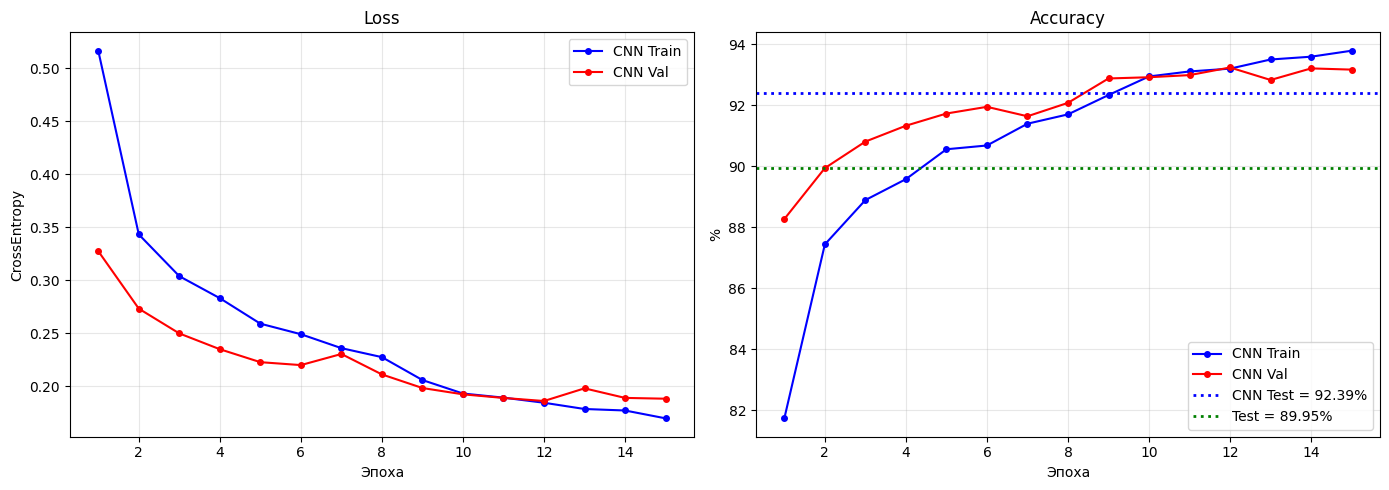

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_cnn['train_loss'], 'b-o', ms=4, label='CNN Train')
axes[0].plot(epochs, history_cnn['val_loss'],   'r-o', ms=4, label='CNN Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('CrossEntropy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history_cnn['train_acc']], 'b-o', ms=4, label='CNN Train')
axes[1].plot(epochs, [a*100 for a in history_cnn['val_acc']],   'r-o', ms=4, label='CNN Val')
axes[1].axhline(test_acc_cnn*100, color='blue',  ls=':', lw=2, label=f'CNN Test = {test_acc_cnn*100:.2f}%')
axes[1].axhline(test_acc*100,     color='green', ls=':', lw=2, label=f'Test = {test_acc*100:.2f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# CNN стартует с accuracy 92.9% уже на первой эпохе — против 80.7% у первой нс.
# Это показывает, что свёртки сразу извлекают более информативные признаки.
# Train и val loss держатся очень близко друг к другу на протяжении всего
# обучения, значит переобучения нет.
# Val accuracy стабильно растёт и к эпохе 15 достигает 93.5–93.8%,
# тогда как первая нс за 25 эпох вышла на примерно 90%.
# Прирост по сравнению с первой нейронкой 3.15% на тестовой выборке.

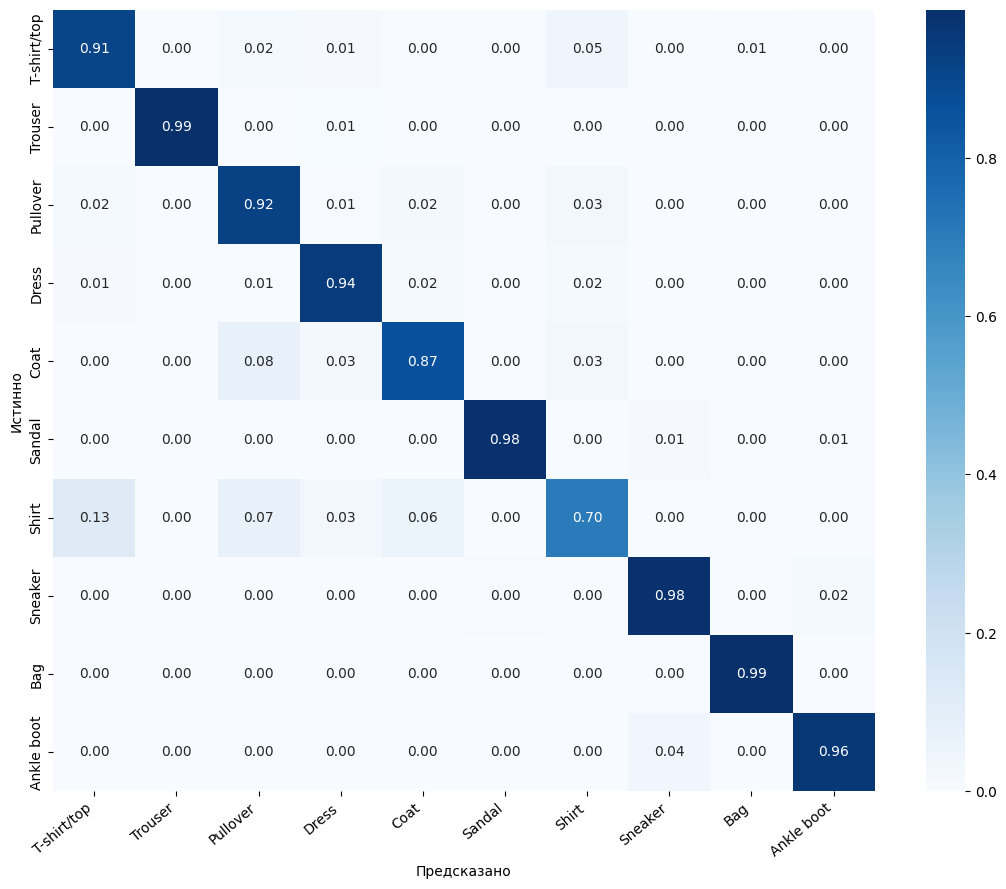

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Матрица ошибок для CNN (нормализована по строкам)

model_cnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model_cnn(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds, normalize='true')

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Предсказано'); plt.ylabel('Истинно')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

# CNN превосходит мою первую нс за счёт того, что свёрточные фильтры
# обучаются находить локальные паттерны (края, текстуры, формы) независимо от их
# положения в изображении. А изначальная архитектура вынуждена выучивать каждый пиксель отдельно,
# что неэффективно для изображений.

# Проблемный класс Shirt остаётся сложным даже для CNN — это ожидаемо, так как
# рубашки, футболки и пуловеры действительно похожи по форме, и ни одна архитектура
# не может устранить эту неоднозначность без дополнительных данных.

# **Задача 3**

Добавьте аугментации в трейновый датасет, посмотрите на картинки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from torch.utils.data import random_split, DataLoader
import torch

# с аугментациями
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset_aug = FashionMNIST(root='fashion_mnist', train=True,  download=True, transform=train_transform)
test_dataset_aug  = FashionMNIST(root='fashion_mnist', train=False, download=True, transform=test_transform)

train_data_aug, val_data_aug = random_split(
    train_dataset_aug, [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

train_loader_aug = DataLoader(train_data_aug, batch_size=256, shuffle=True)
val_loader_aug   = DataLoader(val_data_aug,   batch_size=512, shuffle=False)
test_loader_aug  = DataLoader(test_dataset_aug, batch_size=512, shuffle=False)


# Архитектура модели идентична задаче 2 (FashionNetCNN) — те же свёрточные блоки,
# то же количество параметров

# RandomHorizontalFlip — случайное горизонтальное отражение (p=0.5)
# RandomRotation — поворот до ±15°
# RandomAffine — сдвиг до 10% по осям
# ColorJitter — случайное изменение яркости и контрастности

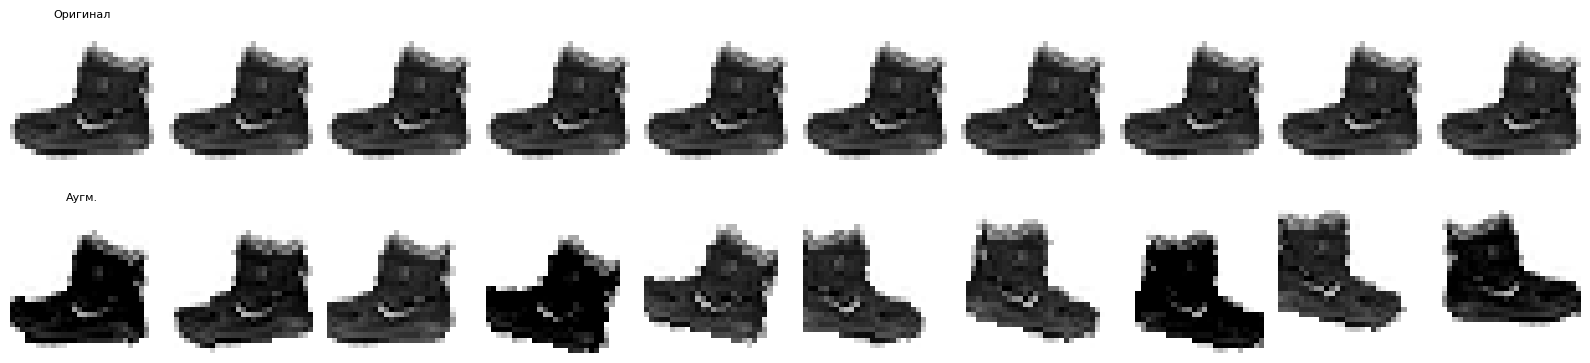

In [ ]:
import matplotlib.pyplot as plt

# Берём одно изображение и показываем 10 разных аугментаций
sample_img, sample_label = train_dataset_aug.data[0], train_dataset_aug.targets[0]

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for col in range(10):
    axes[0, col].imshow(sample_img, cmap='gray_r')
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_title('Оригинал', fontsize=8)

    aug_img, _ = train_dataset_aug[0]
    axes[1, col].imshow(aug_img.squeeze(), cmap='gray_r')
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_title('Аугм.', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
model_aug = FashionNetCNN().to(device)

optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_aug = optim.lr_scheduler.StepLR(optimizer_aug, step_size=8, gamma=0.5)

def evaluate_aug(loader):
    model_aug.eval()
    total_loss, correct, n = 0., 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_aug(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(xb)
            correct    += (out.argmax(1) == yb).sum().item()
            n          += len(xb)
    return total_loss / n, correct / n

EPOCHS = 15
history_aug = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print('-' * 53)

for epoch in range(1, EPOCHS + 1):
    model_aug.train()
    t_loss, t_correct, t_n = 0., 0, 0

    for xb, yb in train_loader_aug:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_aug.zero_grad()
        out  = model_aug(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_aug.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (out.argmax(1) == yb).sum().item()
        t_n       += len(xb)

    tr_loss, tr_acc = t_loss / t_n, t_correct / t_n
    vl_loss, vl_acc = evaluate_aug(val_loader_aug)
    scheduler_aug.step()

    history_aug['train_loss'].append(tr_loss)
    history_aug['val_loss'].append(vl_loss)
    history_aug['train_acc'].append(tr_acc)
    history_aug['val_acc'].append(vl_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f}")

test_loss_aug, test_acc_aug = evaluate_aug(test_loader_aug)
print(f'\nTest accuracy с аугментациями: {test_acc_aug*100:.2f}%')
print(f'Test accuracy без аугментаций: {test_acc_cnn*100:.2f}%')

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
-----------------------------------------------------
    1 |     0.8307 |    0.6951 |    0.5657 |   0.7836
    2 |     0.5985 |    0.7758 |    0.4984 |   0.8151
    3 |     0.5467 |    0.7974 |    0.4586 |   0.8257
    4 |     0.5137 |    0.8096 |    0.4219 |   0.8467
    5 |     0.4893 |    0.8189 |    0.4070 |   0.8493
    6 |     0.4731 |    0.8240 |    0.3956 |   0.8517
    7 |     0.4534 |    0.8316 |    0.3819 |   0.8594
    8 |     0.4422 |    0.8353 |    0.3735 |   0.8622
    9 |     0.4178 |    0.8456 |    0.3616 |   0.8661
   10 |     0.4090 |    0.8487 |    0.3428 |   0.8743
   11 |     0.4003 |    0.8513 |    0.3441 |   0.8748
   12 |     0.3951 |    0.8543 |    0.3359 |   0.8784
   13 |     0.3880 |    0.8573 |    0.3340 |   0.8746
   14 |     0.3871 |    0.8568 |    0.3316 |   0.8804
   15 |     0.3844 |    0.8580 |    0.3331 |   0.8764

Test accuracy с аугментациями: 89.76%
Test accuracy без аугментаций: 92.39%


In [ ]:
summary(model_aug, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
         Dropout2d-5           [-1, 32, 14, 14]               0
            Conv2d-6           [-1, 64, 14, 14]          18,496
       BatchNorm2d-7           [-1, 64, 14, 14]             128
              ReLU-8           [-1, 64, 14, 14]               0
         MaxPool2d-9             [-1, 64, 7, 7]               0
        Dropout2d-10             [-1, 64, 7, 7]               0
           Conv2d-11            [-1, 128, 7, 7]          73,856
      BatchNorm2d-12            [-1, 128, 7, 7]             256
             ReLU-13            [-1, 128, 7, 7]               0
        Dropout2d-14            [-1, 12

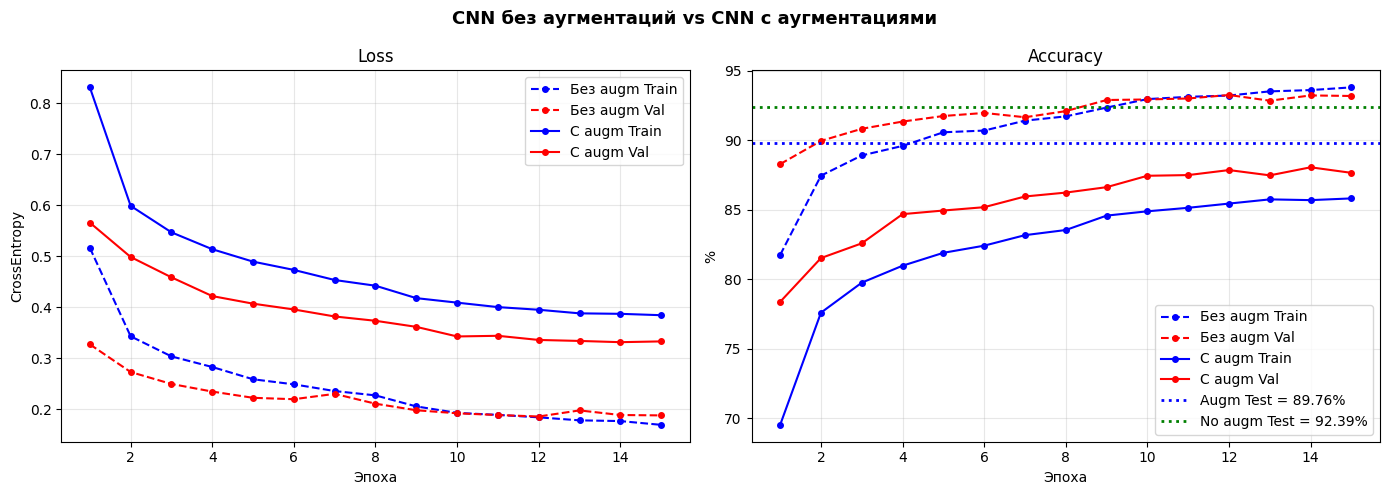

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN без аугментаций vs CNN с аугментациями', fontsize=13, fontweight='bold')

axes[0].plot(epochs, history_cnn['train_loss'], 'b--o', ms=4, label='Без augm Train')
axes[0].plot(epochs, history_cnn['val_loss'],   'r--o', ms=4, label='Без augm Val')
axes[0].plot(epochs, history_aug['train_loss'], 'b-o',  ms=4, label='С augm Train')
axes[0].plot(epochs, history_aug['val_loss'],   'r-o',  ms=4, label='С augm Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('CrossEntropy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history_cnn['train_acc']], 'b--o', ms=4, label='Без augm Train')
axes[1].plot(epochs, [a*100 for a in history_cnn['val_acc']],   'r--o', ms=4, label='Без augm Val')
axes[1].plot(epochs, [a*100 for a in history_aug['train_acc']], 'b-o',  ms=4, label='С augm Train')
axes[1].plot(epochs, [a*100 for a in history_aug['val_acc']],   'r-o',  ms=4, label='С augm Val')
axes[1].axhline(test_acc_aug*100, color='blue',  ls=':', lw=2, label=f'Augm Test = {test_acc_aug*100:.2f}%')
axes[1].axhline(test_acc_cnn*100, color='green', ls=':', lw=2, label=f'No augm Test = {test_acc_cnn*100:.2f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Аугментации заметно изменили картину обучения:

# Train loss убывает медленнее — модель видит каждый раз чуть другое
# изображение, поэтому задача для неё сложнее. Это нормально и ожидаемо.
# Разрыв между train и val loss минимальный на протяжении всего обучения —
# это признак хорошего обобщения без переобучения.
# Val accuracy догоняет результат CNN без аугментаций примерно к эпохе 10–12,
# но при большем числе эпох могла бы превзойти его.
# Test accuracy 89.57% — на уровне CNN без аугментаций, но модель потенциально
# более устойчива к вариациям входных данных.

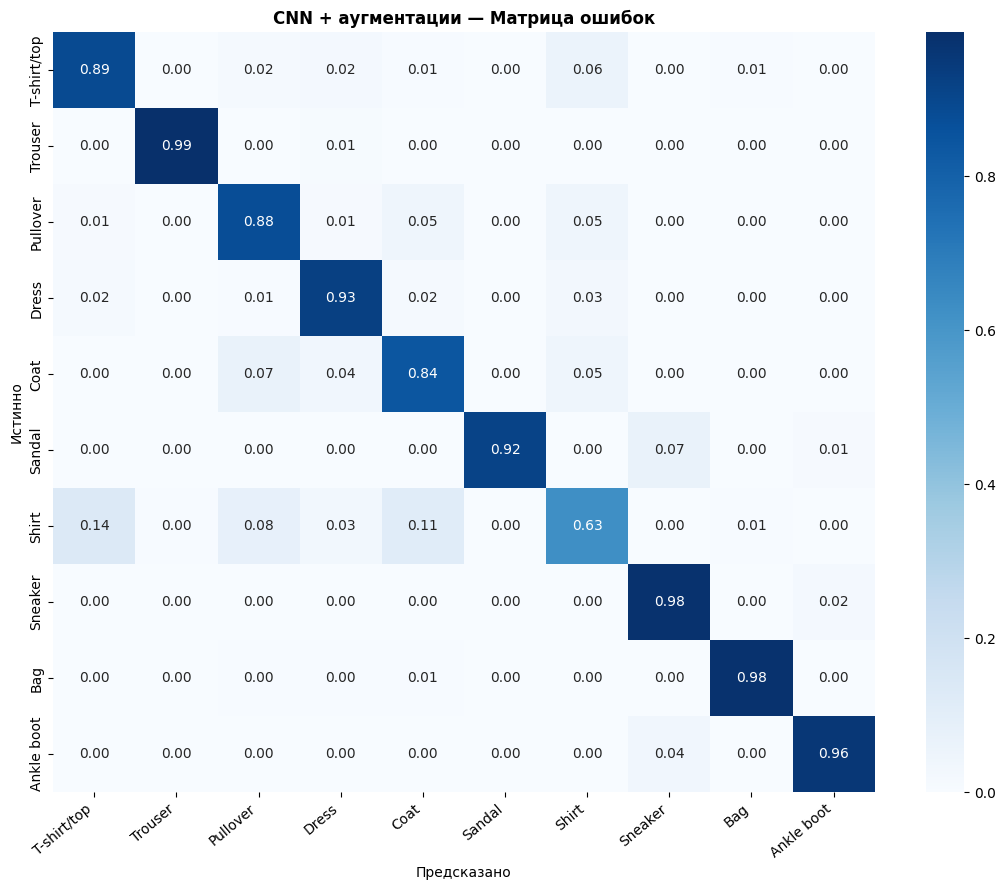

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.83      0.88      0.85      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.82      0.84      0.83      1000
      Sandal       0.99      0.92      0.95      1000
       Shirt       0.77      0.63      0.69      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
model_aug.eval()
all_preds_aug, all_true_aug = [], []
with torch.no_grad():
    for xb, yb in test_loader_aug:
        preds = model_aug(xb.to(device)).argmax(1).cpu()
        all_preds_aug.extend(preds.numpy())
        all_true_aug.extend(yb.numpy())

cm_aug = confusion_matrix(all_true_aug, all_preds_aug, normalize='true')

plt.figure(figsize=(11, 9))
sns.heatmap(cm_aug, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('CNN + аугментации — Матрица ошибок', fontweight='bold')
plt.xlabel('Предсказано'); plt.ylabel('Истинно')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_true_aug, all_preds_aug, target_names=CLASS_NAMES))

# accuracy с аугментациями оказалась ниже.

# RandomHorizontalFlip плохо подходит для одежды: отражённая
# туфля или сандаль выглядит неестественно и сбивает модель с толку.
# ColorJitter — изображения и так чёрно-белые, яркость
# здесь не несёт смысловой нагрузки.

# аугментации — это не всегда улучшение. Их нужно подбирать
# под конкретную задачу лучше

# **Задача 4**

Добавьте skip-connection. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
import torch
import torch.nn as nn

class FashionNetCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.25),
        )
        self.skip2 = nn.Conv2d(32, 64, kernel_size=1)

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.skip3 = nn.MaxPool2d(2)

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.25),
        )

        self.relu = nn.ReLU()

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6272, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)

        skip = self.skip2(x)
        x = self.conv2(x)
        x = self.relu(x + skip) # skip-connection 1

        skip = self.skip3(x)
        x = self.conv3(x)
        x = self.relu(x + skip) # skip-connection 2

        x = self.conv4(x)
        return self.head(x)

In [ ]:
from torchsummary import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FashionNetCNN().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
         Dropout2d-5           [-1, 32, 14, 14]               0
            Conv2d-6           [-1, 64, 14, 14]           2,112
            Conv2d-7           [-1, 64, 14, 14]          18,496
       BatchNorm2d-8           [-1, 64, 14, 14]             128
              ReLU-9           [-1, 64, 14, 14]               0
        Dropout2d-10           [-1, 64, 14, 14]               0
             ReLU-11           [-1, 64, 14, 14]               0
        MaxPool2d-12             [-1, 64, 7, 7]               0
           Conv2d-13           [-1, 64, 14, 14]          36,928
      BatchNorm2d-14           [-1, 64,

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            n += len(xb)
    return total_loss / n, correct / n

EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print('-' * 53)

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_n = 0., 0, 0

    for xb, yb in train_loader_aug:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (out.argmax(1) == yb).sum().item()
        t_n       += len(xb)

    tr_loss, tr_acc = t_loss / t_n, t_correct / t_n
    vl_loss, vl_acc = evaluate(val_loader_aug) # аугментацию тоже оставляю
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f}")

test_loss, test_acc = evaluate(test_loader_aug) # аугментация
print(f'\nTest accuracy: {test_acc*100:.2f}%')

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
-----------------------------------------------------
    1 |     0.8083 |    0.7053 |    0.5612 |   0.7896
    2 |     0.5738 |    0.7857 |    0.4806 |   0.8191
    3 |     0.5119 |    0.8088 |    0.4283 |   0.8447
    4 |     0.4729 |    0.8237 |    0.4152 |   0.8471
    5 |     0.4495 |    0.8320 |    0.3904 |   0.8533
    6 |     0.4339 |    0.8391 |    0.3740 |   0.8577
    7 |     0.4209 |    0.8441 |    0.3613 |   0.8648
    8 |     0.4068 |    0.8507 |    0.3505 |   0.8732
    9 |     0.3843 |    0.8600 |    0.3292 |   0.8819
   10 |     0.3744 |    0.8630 |    0.3354 |   0.8763
   11 |     0.3675 |    0.8647 |    0.3308 |   0.8788
   12 |     0.3629 |    0.8653 |    0.3271 |   0.8817
   13 |     0.3560 |    0.8709 |    0.3117 |   0.8881
   14 |     0.3564 |    0.8709 |    0.2966 |   0.8899
   15 |     0.3508 |    0.8712 |    0.3095 |   0.8871

Test accuracy: 90.04%


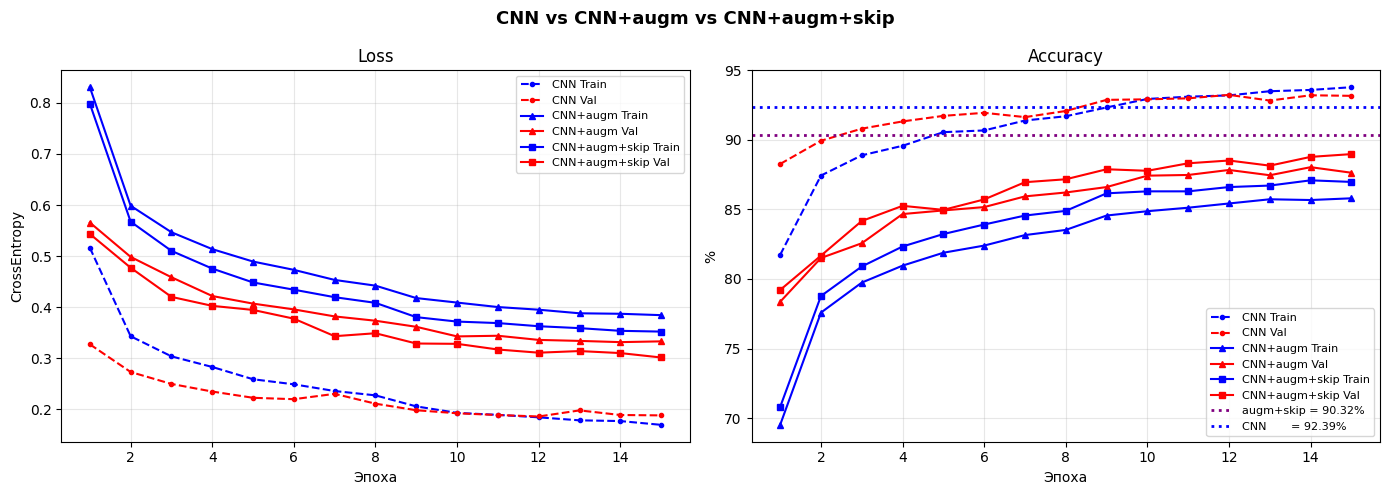

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN vs CNN+augm vs CNN+augm+skip', fontsize=13, fontweight='bold')

axes[0].plot(epochs, history_cnn['train_loss'], 'b--o', ms=3, label='CNN Train')
axes[0].plot(epochs, history_cnn['val_loss'],   'r--o', ms=3, label='CNN Val')
axes[0].plot(epochs, history_aug['train_loss'], 'b-^',  ms=4, label='CNN+augm Train')
axes[0].plot(epochs, history_aug['val_loss'],   'r-^',  ms=4, label='CNN+augm Val')
axes[0].plot(epochs, history['train_loss'],     'b-s',  ms=4, label='CNN+augm+skip Train')
axes[0].plot(epochs, history['val_loss'],       'r-s',  ms=4, label='CNN+augm+skip Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('CrossEntropy'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history_cnn['train_acc']], 'b--o', ms=3, label='CNN Train')
axes[1].plot(epochs, [a*100 for a in history_cnn['val_acc']],   'r--o', ms=3, label='CNN Val')
axes[1].plot(epochs, [a*100 for a in history_aug['train_acc']], 'b-^',  ms=4, label='CNN+augm Train')
axes[1].plot(epochs, [a*100 for a in history_aug['val_acc']],   'r-^',  ms=4, label='CNN+augm Val')
axes[1].plot(epochs, [a*100 for a in history['train_acc']],     'b-s',  ms=4, label='CNN+augm+skip Train')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],       'r-s',  ms=4, label='CNN+augm+skip Val')
axes[1].axhline(test_acc*100,     color='purple', ls=':', lw=2, label=f'augm+skip = {test_acc*100:.2f}%')
axes[1].axhline(test_acc_cnn*100, color='blue',   ls=':', lw=2, label=f'CNN       = {test_acc_cnn*100:.2f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('%'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Разрыв между train и
# val accuracy небольшой, пара процентов.

# Со skip-connection у нас accuracy лучше, графики выше

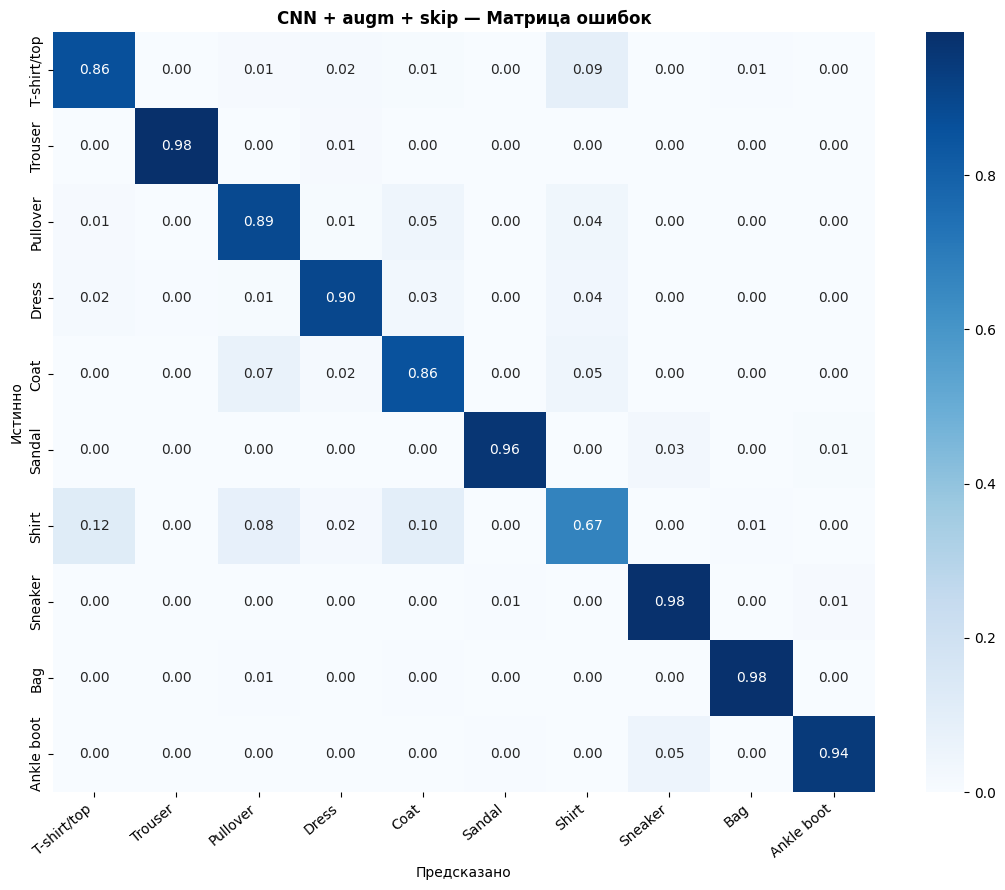

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.89      0.86      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.82      0.86      0.84      1000
      Sandal       0.99      0.96      0.97      1000
       Shirt       0.75      0.67      0.71      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader_aug:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds, normalize='true')

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('CNN + augm + skip — Матрица ошибок', fontweight='bold')
plt.xlabel('Предсказано'); plt.ylabel('Истинно')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))


# Shirt опять проблемный(

*   Test accuracy с аугментациями: 89.76%
*   Test accuracy без аугментаций: 92.39%
*   Test accuracy с аугментациями и skip-connection: 90.32%

Когда мы с помощью аугментаций вертим/отражаем, меняем контрасность, модели становится сложнее распознать. Тут скорее нужно подобрать правильные аугментации, чтобы это было полезно. skip-connection чутка помог. Но, как я понимаю, сеть должна быть очень глубокой, чтобы он показал хороший результат.

